# LangGraph Planner 비교 실험

## tl;dr

저장 실행: LLM 67%, BFS/A*/하이브리드 100% 성공.

## Experiment Goal

- Random, BFS, push 기반 A*, LLM, LLM+Search Guard를 동일한 레벨과 seed에서 비교한다.
- 성공률, 행동 수, 계획 오류·재시도, 알고리즘 폴백과 LLM 응답 시간을 측정한다.
- 위에서 아래로 실행한 현재 결과를 노트북에 저장한다.

## Context & Methods

상태 배열을 표준 Sokoban 문자 보드로 직렬화하고, 모델에는 `{"action":"UP"}` 형태의 JSON Schema 출력을 요구한다. LangGraph가 응답 형식, 이동 가능 여부와 재시도 흐름을 검증·실행한다.

### Key Assumptions

- `.env`의 Ollama 서버와 모델이 실행 시점에 사용 가능하다.
- `temperature=0`과 episode seed를 모델 호출에 전달하지만, 런타임·모델 버전에 따라 완전한 결정성은 보장되지 않는다.
- `heldout-turn`은 제품 기본 레벨에 포함하지 않은 실험용 소형 레벨이다.
- 실행 시간은 로컬/원격 Ollama 상태의 영향을 받는다.

### 1. Load dependencies and fixed parameters

In [1]:
from dataclasses import asdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, Markdown, display
from matplotlib import animation

from sokoban_agent.env import (
    DEFAULT_LEVELS,
    FixedLevelProvider,
    SokobanEnv,
    parse_level,
)
from sokoban_agent.evaluation import (
    run_benchmark_traces,
    summarize_by_planner,
)
from sokoban_agent.planning import (
    AStarPlanner,
    BFSPlanner,
    LLMPlanner,
    RandomPlanner,
    SearchGuardPlanner,
)
from sokoban_agent.planning.llm import (
    OllamaClient,
    OllamaSettings,
)

pd.set_option('display.max_columns', None)

LEVEL_IDS = ['tiny-push', 'tiny-walk', 'heldout-turn']
SEEDS = [0, 1]
MAX_STEPS = 15
MAX_ATTEMPTS = 3

settings = OllamaSettings.from_env()
experiment_config = {
    'model': settings.model,
    'temperature': settings.temperature,
    'num_ctx': settings.num_ctx,
    'max_output_tokens': settings.max_output_tokens,
    'think': settings.think,
    'level_ids': LEVEL_IDS,
    'seeds': SEEDS,
    'max_steps': MAX_STEPS,
    'max_planning_attempts': MAX_ATTEMPTS,
}
experiment_config

{'model': 'qwen3.6:27b-mlx',
 'temperature': 0.0,
 'num_ctx': 4096,
 'max_output_tokens': 128,
 'think': False,
 'level_ids': ['tiny-push', 'tiny-walk', 'heldout-turn'],
 'seeds': [0, 1],
 'max_steps': 15,
 'max_planning_attempts': 3}

## Data

### 2. Build the fixed and held-out level cohort

In [2]:
heldout_level = parse_level(
    'heldout-turn',
    [
        '#####',
        '#.  #',
        '# $ #',
        '#  @#',
        '#####',
    ],
)
level_provider = FixedLevelProvider(
    [
        DEFAULT_LEVELS.get('tiny-push'),
        DEFAULT_LEVELS.get('tiny-walk'),
        heldout_level,
    ]
)
LEVEL_IDS

['tiny-push', 'tiny-walk', 'heldout-turn']

### 3. Run identical cases

In [3]:
client = OllamaClient(settings)
warmup = client.complete('Reply with READY only.')
print({'warmup_seconds': warmup.metrics.total_seconds})
planners = [
    RandomPlanner(),
    BFSPlanner(),
    AStarPlanner(),
    LLMPlanner(
        client,
        model_name=settings.model,
    ),
    SearchGuardPlanner(
        LLMPlanner(client, model_name=settings.model),
        algorithm='bfs',
    ),
    SearchGuardPlanner(
        LLMPlanner(client, model_name=settings.model),
        algorithm='astar',
    ),
]
env = SokobanEnv(
    level_provider=level_provider,
    max_steps=MAX_STEPS,
)
try:
    traces = run_benchmark_traces(
        env,
        planners,
        level_ids=LEVEL_IDS,
        seeds=SEEDS,
        max_planning_attempts=MAX_ATTEMPTS,
    )
finally:
    env.close()

results = [trace.result for trace in traces]
results_df = pd.DataFrame.from_records(
    asdict(result) for result in results
)
results_df

{'warmup_seconds': 0.536356042}


,planner_name,level_id,seed,success,deadlock,truncated,action_count,invalid_moves,total_reward,elapsed_seconds,failure_reason,planning_calls,planning_retries,planning_errors,planning_elapsed_seconds,algorithm_calls,algorithm_fallbacks,algorithm_expanded_states,algorithm_elapsed_seconds,llm_calls,llm_retries,llm_client_errors,llm_format_errors,llm_invalid_actions,llm_elapsed_seconds,llm_load_seconds,llm_prompt_eval_seconds,llm_eval_seconds,llm_prompt_tokens,llm_output_tokens
0,graph:random,tiny-push,0,False,False,False,9,7,-0.9,0.022967,plan action 1 (DOWN) is blocked,16,6,0,0.000223,0,0,0,0.000000,0,0,0,0,0,0.000000,0.000000,0.000000e+00,0.000000,0,0
1,graph:random,tiny-push,1,False,False,False,5,4,-0.5,0.008668,plan action 1 (UP) is blocked,9,3,0,0.000116,0,0,0,0.000000,0,0,0,0,0,0.000000,0.000000,0.000000e+00,0.000000,0,0
2,graph:random,tiny-walk,0,False,False,False,0,3,0.0,0.002704,plan action 1 (DOWN) is blocked,3,2,0,0.000020,0,0,0,0.000000,0,0,0,0,0,0.000000,0.000000,0.000000e+00,0.000000,0,0
3,graph:random,tiny-walk,1,False,False,False,4,5,-0.4,0.007415,plan action 1 (UP) is blocked,9,4,0,0.000055,0,0,0,0.000000,0,0,0,0,0,0.000000,0.000000,0.000000e+00,0.000000,0,0
4,graph:random,heldout-turn,0,False,False,False,8,8,-0.8,0.011691,plan action 1 (DOWN) is blocked,16,7,0,0.000084,0,0,0,0.000000,0,0,0,0,0,0.000000,0.000000,0.000000e+00,0.000000,0,0
5,graph:random,heldout-turn,1,False,False,False,4,5,-0.4,0.005687,plan action 1 (UP) is blocked,9,4,0,0.000036,0,0,0,0.000000,0,0,0,0,0,0.000000,0.000000,0.000000e+00,0.000000,0,0
6,graph:bfs,tiny-push,0,True,False,False,1,0,10.9,0.001526,NaN,1,0,0,0.000039,1,0,1,0.000030,0,0,0,0,0,0.000000,0.000000,0.000000e+00,0.000000,0,0
7,graph:bfs,tiny-push,1,True,False,False,1,0,10.9,0.001381,NaN,1,0,0,0.000027,1,0,1,0.000022,0,0,0,0,0,0.000000,0.000000,0.000000e+00,0.000000,0,0
8,graph:bfs,tiny-walk,0,True,False,False,5,0,10.5,0.003100,NaN,1,0,0,0.000100,1,0,20,0.000095,0,0,0,0,0,0.000000,0.000000,0.000000e+00,0.000000,0,0
9,graph:bfs,tiny-walk,1,True,False,False,5,0,10.5,0.003144,NaN,1,0,0,0.000089,1,0,20,0.000084,0,0,0,0,0,0.000000,0.000000,0.000000e+00,0.000000,0,0


## Results

### 4. Compare success, efficiency, recovery, and latency

In [4]:
summary_df = pd.DataFrame.from_records(
    asdict(summary) for summary in summarize_by_planner(results)
).set_index('planner_name')
summary_columns = [
    'episode_count',
    'success_count',
    'success_rate',
    'mean_actions',
    'mean_actions_on_success',
    'mean_elapsed_seconds',
    'p50_elapsed_seconds',
    'p95_elapsed_seconds',
    'total_algorithm_calls',
    'total_algorithm_fallbacks',
    'total_algorithm_expanded_states',
    'mean_algorithm_elapsed_seconds',
    'total_llm_calls',
    'total_llm_retries',
    'total_llm_format_errors',
    'total_llm_invalid_actions',
    'mean_llm_elapsed_seconds',
    'p50_llm_elapsed_seconds',
    'p95_llm_elapsed_seconds',
    'total_llm_prompt_tokens',
    'total_llm_output_tokens',
    'llm_output_tokens_per_second',
]
summary_df[summary_columns]

,episode_count,success_count,success_rate,mean_actions,mean_actions_on_success,mean_elapsed_seconds,p50_elapsed_seconds,p95_elapsed_seconds,total_algorithm_calls,total_algorithm_fallbacks,total_algorithm_expanded_states,mean_algorithm_elapsed_seconds,total_llm_calls,total_llm_retries,total_llm_format_errors,total_llm_invalid_actions,mean_llm_elapsed_seconds,p50_llm_elapsed_seconds,p95_llm_elapsed_seconds,total_llm_prompt_tokens,total_llm_output_tokens,llm_output_tokens_per_second
planner_name,,,,,,,,,,,,,,,,,,,,,,
graph:random,6,0,0.000000,5.000000,NaN,0.009855,0.008041,0.020148,0,0,0,0.000000,0,0,0,0,0.000000,0.000000,0.000000,0,0,NaN
graph:bfs,6,6,1.000000,3.666667,3.666667,0.002621,0.003122,0.003328,6,0,84,0.000072,0,0,0,0,0.000000,0.000000,0.000000,0,0,NaN
graph:astar,6,6,1.000000,3.666667,3.666667,0.002814,0.003304,0.003803,6,0,10,0.000081,0,0,0,0,0.000000,0.000000,0.000000,0,0,NaN
graph:llm:qwen3.6:27b-mlx,6,4,0.666667,7.666667,4.000000,7.598924,4.752838,18.987135,0,0,0,0.000000,39,7,0,7,7.574736,4.733033,18.936982,6672,545,26.348904
graph:hybrid:graph:llm:qwen3.6:27b-mlx+bfs,6,6,1.000000,3.666667,3.666667,1.650053,1.638170,2.726812,4,2,58,0.000265,6,0,0,0,1.639205,1.629304,2.713802,972,96,25.893775
graph:hybrid:graph:llm:qwen3.6:27b-mlx+astar,6,6,1.000000,3.666667,3.666667,0.959648,0.960037,1.144811,4,2,6,0.000105,6,0,0,0,0.953166,0.955258,1.139952,972,96,26.629819


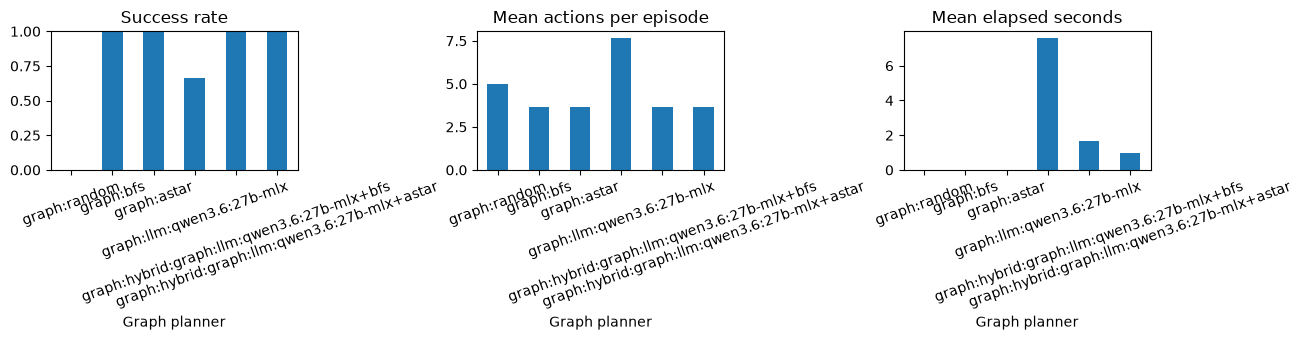

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
summary_df['success_rate'].plot.bar(
    ax=axes[0], ylim=(0, 1), title='Success rate'
)
summary_df['mean_actions'].plot.bar(
    ax=axes[1], title='Mean actions per episode'
)
summary_df['mean_elapsed_seconds'].plot.bar(
    ax=axes[2], title='Mean elapsed seconds'
)
for axis in axes:
    axis.set_xlabel('Graph planner')
    axis.tick_params(axis='x', rotation=20)
fig.tight_layout()
plt.show()

### 5. Inspect LLM failures by level and seed

In [6]:
llm_name = f'graph:llm:{settings.model}'
hybrid_name = f'graph:hybrid:{llm_name}+astar'
llm_columns = [
    'level_id',
    'seed',
    'success',
    'deadlock',
    'truncated',
    'action_count',
    'llm_calls',
    'llm_retries',
    'llm_client_errors',
    'llm_format_errors',
    'llm_invalid_actions',
    'llm_elapsed_seconds',
    'llm_prompt_tokens',
    'llm_output_tokens',
    'failure_reason',
]
llm_results_df = results_df[
    results_df['planner_name'] == llm_name
][llm_columns]
llm_results_df

,level_id,seed,success,deadlock,truncated,action_count,llm_calls,llm_retries,llm_client_errors,llm_format_errors,llm_invalid_actions,llm_elapsed_seconds,llm_prompt_tokens,llm_output_tokens,failure_reason
18,tiny-push,0,True,False,False,1,1,0,0,0,0,0.953255,161,17,NaN
19,tiny-push,1,True,False,False,1,1,0,0,0,0,0.835409,161,17,NaN
20,tiny-walk,0,True,False,False,7,4,0,0,0,0,5.470313,659,72,NaN
21,tiny-walk,1,True,False,False,7,4,0,0,0,0,3.995752,659,72,NaN
22,heldout-turn,0,False,False,True,15,17,5,0,0,5,20.777121,2982,209,NaN
23,heldout-turn,1,False,False,True,15,12,2,0,0,2,13.416564,2050,158,NaN


### 6. Replay exact agent movement

기본 선택은 장기 계획 실패가 드러나는 LLM의 `tiny-walk`, seed 0 에피소드다. `ANIMATION_CASE`를 바꾸면 같은 실험의 다른 Planner 경로도 재생할 수 있다. 표와 영상에는 환경이 실제로 실행한 행동만 포함된다.

In [7]:
ANIMATION_CASE = {
    'planner_name': llm_name,
    'level_id': 'tiny-walk',
    'seed': 0,
}
selected_trace = next(
    trace
    for trace in traces
    if trace.result.planner_name == ANIMATION_CASE['planner_name']
    and trace.result.level_id == ANIMATION_CASE['level_id']
    and trace.result.seed == ANIMATION_CASE['seed']
)

action_log_df = pd.DataFrame.from_records(
    {
        'frame': frame.index,
        'action': (
            frame.action.name
            if frame.action is not None
            else 'RESET'
        ),
        'invalid_move': frame.invalid_move,
        'pushed': frame.pushed,
        'success': frame.success,
        'deadlock': frame.deadlock,
    }
    for frame in selected_trace.frames
)
action_log_df

,frame,action,invalid_move,pushed,success,deadlock
0,0,RESET,False,False,False,False
1,1,RIGHT,False,False,False,False
2,2,UP,False,True,False,False
3,3,RIGHT,False,False,False,False
4,4,LEFT,False,False,False,False
5,5,LEFT,False,False,False,False
6,6,UP,False,False,False,False
7,7,RIGHT,False,True,True,False


In [8]:
RGB_PALETTE = np.asarray(
    [
        [238, 238, 238], [45, 45, 45], [255, 196, 64],
        [139, 90, 43], [55, 126, 184], [76, 175, 80],
        [126, 87, 194],
    ],
    dtype=np.uint8,
)

def animate_episode_trace(trace, interval_ms=700):
    fig, axis = plt.subplots(figsize=(4.5, 4.5))
    image = axis.imshow(
        RGB_PALETTE[trace.frames[0].observation]
    )
    axis.set_xticks([])
    axis.set_yticks([])
    title = axis.set_title('')

    def update(frame_index):
        frame = trace.frames[frame_index]
        image.set_data(RGB_PALETTE[frame.observation])
        action_name = (
            frame.action.name
            if frame.action is not None
            else 'RESET'
        )
        if frame.success:
            status = 'SUCCESS'
        elif frame.deadlock:
            status = 'DEADLOCK'
        elif frame_index == len(trace.frames) - 1:
            status = (
                'STEP LIMIT'
                if trace.result.truncated
                else 'STOPPED'
            )
        else:
            status = 'RUNNING'
        title.set_text(
            f"{trace.result.planner_name} | "
            f"{trace.result.level_id} | "
            f"frame {frame.index} | {action_name} | {status}"
        )
        return image, title

    episode_animation = animation.FuncAnimation(
        fig,
        update,
        frames=len(trace.frames),
        interval=interval_ms,
        repeat=True,
        blit=False,
    )
    html = episode_animation.to_jshtml(default_mode='loop')
    plt.close(fig)
    return HTML(html)

display(animate_episode_trace(selected_trace))

### 7. Validate the comparison cohort

In [9]:
case_sets = {
    planner_name: set(
        zip(group['level_id'], group['seed'], strict=True)
    )
    for planner_name, group in results_df.groupby('planner_name')
}
expected_cases = set(
    (level_id, seed)
    for level_id in LEVEL_IDS
    for seed in SEEDS
)
assert all(cases == expected_cases for cases in case_sets.values())
assert summary_df.loc['graph:bfs', 'success_rate'] == 1.0
assert summary_df.loc['graph:astar', 'success_rate'] == 1.0
assert summary_df.loc[llm_name, 'total_llm_client_errors'] == 0
assert summary_df.loc[hybrid_name, 'total_algorithm_calls'] > 0
assert len(selected_trace.frames) == (
    selected_trace.result.action_count + 1
)
assert action_log_df['action'].eq('RESET').sum() == 1
{name: len(cases) for name, cases in case_sets.items()}

{'graph:astar': 6,
 'graph:bfs': 6,
 'graph:hybrid:graph:llm:qwen3.6:27b-mlx+astar': 6,
 'graph:hybrid:graph:llm:qwen3.6:27b-mlx+bfs': 6,
 'graph:llm:qwen3.6:27b-mlx': 6,
 'graph:random': 6}

## Takeaways

In [10]:
llm_summary = summary_df.loc[llm_name]
hybrid_summary = summary_df.loc[hybrid_name]
bfs_summary = summary_df.loc['graph:bfs']
astar_summary = summary_df.loc['graph:astar']
solved_levels = llm_results_df.loc[
    llm_results_df['success'], 'level_id'
].value_counts().to_dict()
display(Markdown(
    f'- LLM은 {int(llm_summary.success_count)}/'
    f'{int(llm_summary.episode_count)} 에피소드를 해결했다 '
    f'({llm_summary.success_rate:.0%}).\n'
    f'- BFS는 같은 cohort에서 '
    f'{bfs_summary.success_rate:.0%} 성공했다.\n'
    f'- push 기반 A*는 {astar_summary.success_rate:.0%} 성공했고 '
    f'평균 탐색 시간은 '
    f'{astar_summary.mean_algorithm_elapsed_seconds:.4f}초였다.\n'
    f'- LLM+A* Search Guard는 '
    f'{hybrid_summary.success_rate:.0%} 성공했고, A* 폴백은 '
    f'{int(hybrid_summary.total_algorithm_fallbacks)}회였다.\n'
    f'- LLM의 총 호출은 {int(llm_summary.total_llm_calls)}회, '
    f'재시도는 {int(llm_summary.total_llm_retries)}회, '
    f'막힌 행동 거절은 '
    f'{int(llm_summary.total_llm_invalid_actions)}회였다.\n'
    f'- 성공 레벨별 횟수: `{solved_levels}`. 이 결과는 소형 '
    '3개 레벨의 탐색 실험이며 전체 Boxoban 성능을 대표하지 않는다.'
))

- LLM은 4/6 에피소드를 해결했다 (67%).
- BFS는 같은 cohort에서 100% 성공했다.
- push 기반 A*는 100% 성공했고 평균 탐색 시간은 0.0001초였다.
- LLM+A* Search Guard는 100% 성공했고, A* 폴백은 2회였다.
- LLM의 총 호출은 39회, 재시도는 7회, 막힌 행동 거절은 7회였다.
- 성공 레벨별 횟수: `{'tiny-push': 2, 'tiny-walk': 2}`. 이 결과는 소형 3개 레벨의 탐색 실험이며 전체 Boxoban 성능을 대표하지 않는다.